In [1]:
!uv pip install PyMuPDF

Using Python 3.12.3 environment at: /opt/venv
Resolved 1 package in 223ms                                          
Prepared 1 package in 1.86s                                              
Installed 1 package in 11ms                                 
 + pymupdf==1.27.1


In [2]:
import fitz  # PyMuPDF
from PIL import Image

def pdf_to_images(pdf_path, zoom=2):
    """Convert PDF pages to images and return as list"""
    images = []
    
    pdf_document = fitz.open(pdf_path)
    
    for page_num in range(len(pdf_document)):
        page = pdf_document[page_num]
        pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
        # Convert pix to PIL Image
        pil_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(pil_image)
        print(f"Processed page {page_num + 1}")
    
    pdf_document.close()
    return images

# Usage
image_list = pdf_to_images("./Movex_Plastic_Chain_820_Product_Update.pdf")

Processed page 1
MuPDF error: format error: No common ancestor in structure tree

Processed page 2
MuPDF error: format error: No common ancestor in structure tree

Processed page 3
MuPDF error: format error: No common ancestor in structure tree

Processed page 4
MuPDF error: format error: No common ancestor in structure tree

Processed page 5
Processed page 6


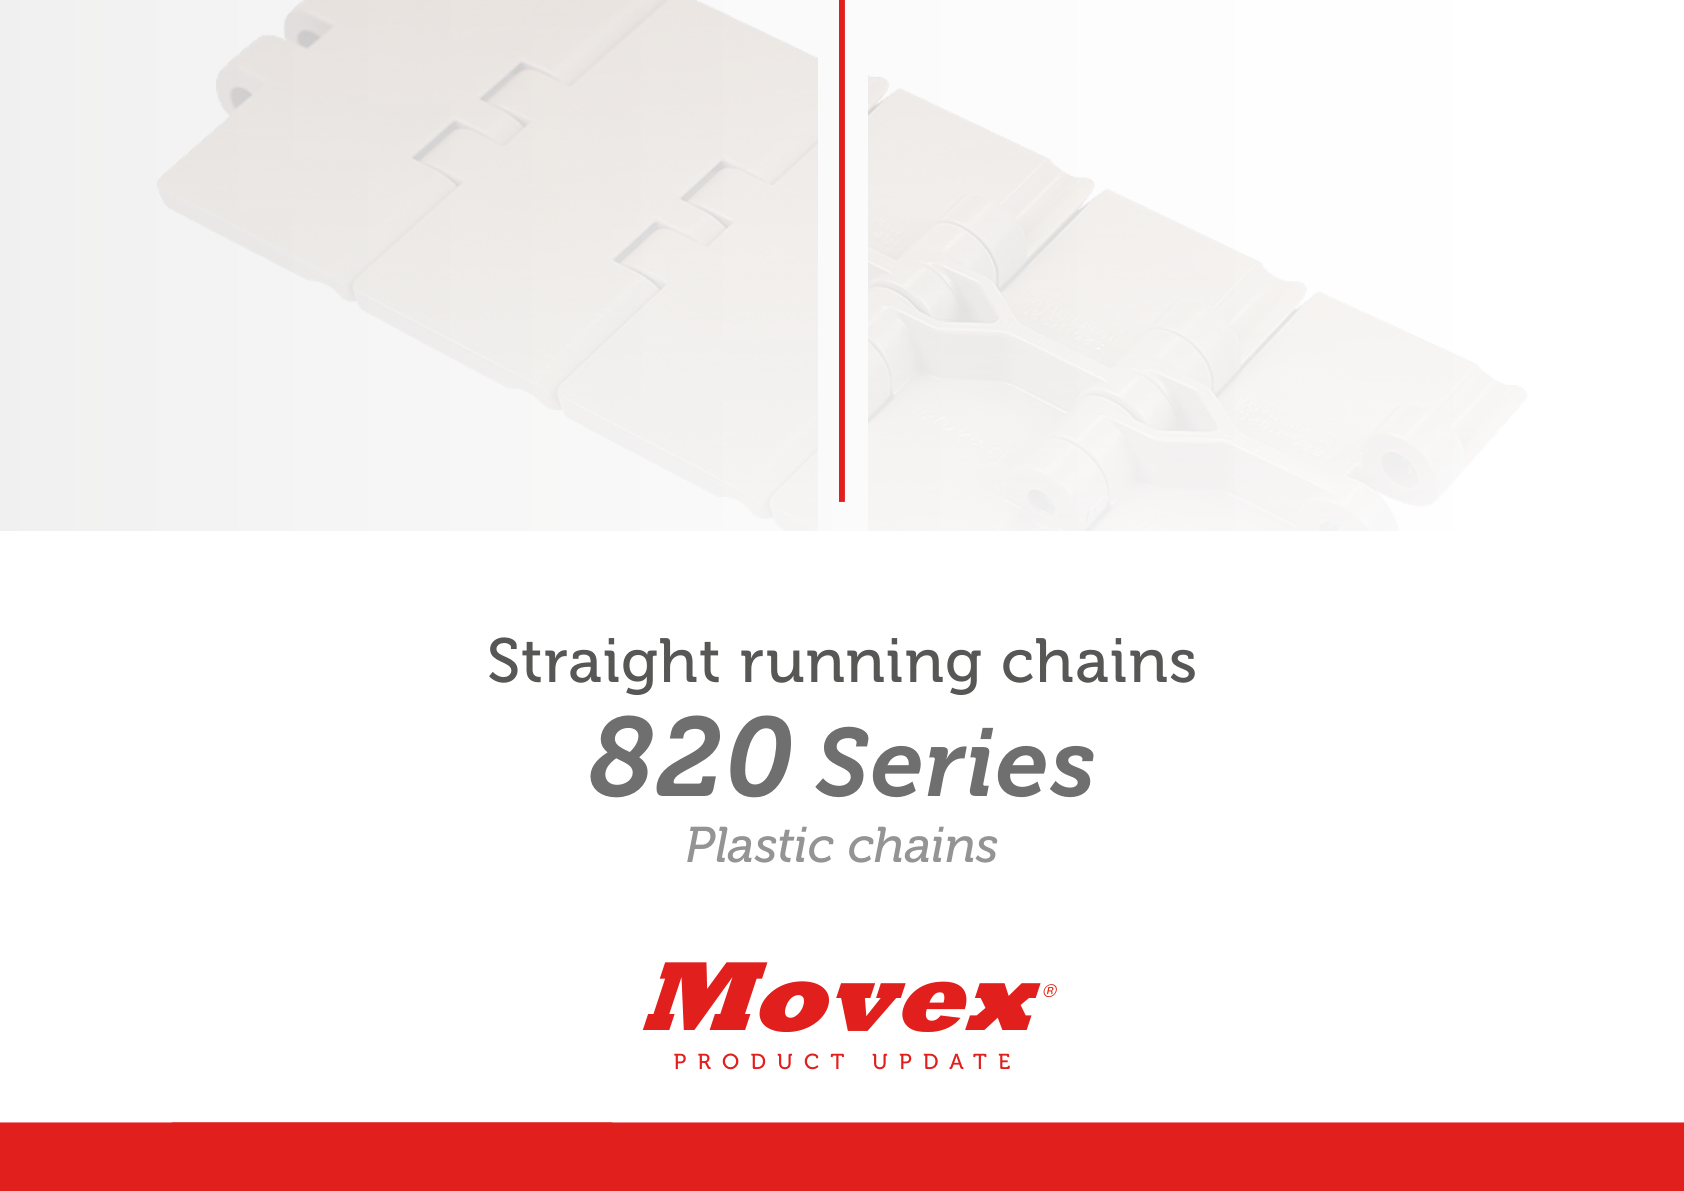

In [4]:
image_list[0]

Displaying 6 pages:
--- Page 1 ---


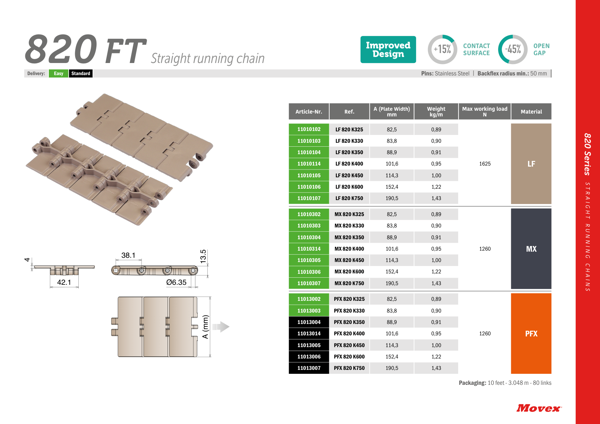

--- Page 2 ---


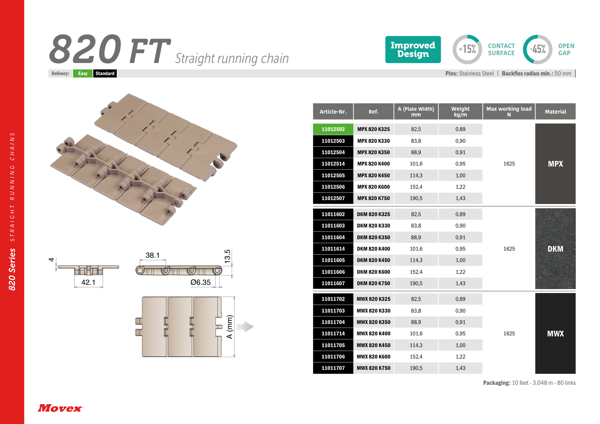

--- Page 3 ---


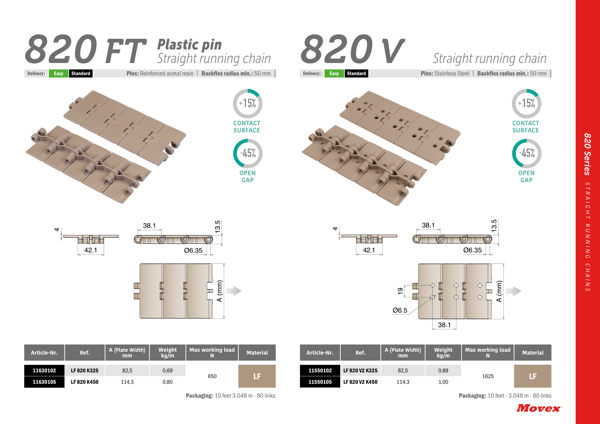

In [13]:
from IPython.display import display

# Define your display size (width, height)
display_size = (600, 800) 

print(f"Displaying {len(image_list)} pages:")

for i, img in enumerate(image_list[2:-1]):
    print(f"--- Page {i+1} ---")
    # Create a copy to avoid modifying the original high-res image
    img_display = img.copy()
    
    # Use .thumbnail() to resize while maintaining aspect ratio
    img_display.thumbnail(display_size)
    
    display(img_display)